# EEP 153 Project 4: Tanzania Demand and Nutrient Policy Analysis

This notebook estimates a food demand system for Tanzania, maps predicted food demand into nutrient demand using a food composition table, and simulates a simple iron-focused food subsidy.

The main policy experiment is a 20% price subsidy on an iron-rich food selected from the available data. The notebook currently completes the demand estimation and nutrient mapping portions of the project. The main remaining limitation is that the Tanzania files do not include an RDI/RDA table, so the notebook cannot yet compute household nutrient adequacy ratios.

## 1. Environment setup

This cell prepares the Python environment for the notebook. We use `%matplotlib inline` so plots appear inside the notebook. We also check whether the `cfe` package is installed. If it is missing, the cell installs `CFEDemands`, which provides the demand-estimation tools used later in the project.

In [1]:
%matplotlib inline

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("cfe") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "CFEDemands"])

## 2. Import packages

This cell imports the packages used throughout the notebook.

- `pathlib` helps locate local CSV files on JupyterHub.
- `numpy` and `pandas` are used for data cleaning and table operations.
- `matplotlib` is used for graphs.
- `cfe.regression` is used to estimate the food demand system.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cfe.regression as rgsn

## 3. Locate the Tanzania data files

This cell searches the JupyterHub home directory for Tanzania CSV files and automatically selects the folder containing the most Tanzania-related files.

This avoids hard-coding a path that might be different for another person running the notebook. The output lists the folder being used and the CSV files found there. For our run, the notebook found the Tanzania project folder and the key files: food expenditures, food prices, household characteristics, region features, and the food composition table.

In [3]:
HOME = Path.home()

print("Current working directory:")
print(Path.cwd())

# Search for Tanzania CSVs anywhere under /home/jovyan.
all_csvs = sorted(HOME.rglob("*.csv"))

tanzania_csvs = [
    p for p in all_csvs
    if "tanzania" in p.name.lower()
]

if len(tanzania_csvs) == 0:
    raise FileNotFoundError(
        "No Tanzania CSV files were found anywhere under /home/jovyan. "
        "Check that the CSVs are actually uploaded to JupyterHub."
    )

# Pick the folder containing the most Tanzania CSVs.
candidate_dirs = sorted(
    set(p.parent for p in tanzania_csvs),
    key=lambda d: sum(1 for p in tanzania_csvs if p.parent == d),
    reverse=True
)

DATA_DIR = candidate_dirs[0]

CSV_FILES = sorted(DATA_DIR.glob("*.csv"))

print("\nUsing data folder:")
print(DATA_DIR)

print("\nCSV files found in that folder:")
for p in CSV_FILES:
    print(" -", repr(p.name))

Current working directory:
/home/jovyan/EEP153_Borlaug/Project 4 - Tanzania

Using data folder:
/home/jovyan/EEP153_Borlaug/Project 4 - Tanzania

CSV files found in that folder:
 - 'Tanzania - FCT.csv'
 - 'Tanzania - Food Expenditures (2019-20).csv'
 - 'Tanzania - Food Expenditures (2020-21).csv'
 - 'Tanzania - Food Prices (2019-20).csv'
 - 'Tanzania - Food Prices (2020-21).csv'
 - 'Tanzania - Household Characteristics.csv'
 - 'Tanzania - Region Features.csv'


## 4. Helper functions for file loading and cleaning

This cell defines helper functions that make the rest of the notebook easier to read and more robust.

The functions do five main things:

1. Find the correct CSV file based on words in the filename.
2. Read CSV files.
3. Drop extra `Unnamed` columns created by spreadsheet exports.
4. Standardize key ID columns like `i`, `t`, `m`, `j`, and `u`.
5. Convert numeric-looking columns into actual numbers.

These helper functions are used repeatedly when loading expenditures, prices, household characteristics, and the food composition table.

In [4]:
def pick_csv(must_words, label, exclude_words=None):
    """
    Finds one CSV file whose filename contains all words in must_words.
    Matching is case-insensitive.
    """
    if exclude_words is None:
        exclude_words = []

    must_words = [w.lower() for w in must_words]
    exclude_words = [w.lower() for w in exclude_words]

    matches = []

    for p in CSV_FILES:
        name = p.name.lower()
        if all(w in name for w in must_words) and not any(w in name for w in exclude_words):
            matches.append(p)

    if len(matches) == 0:
        print("\nAvailable CSV files were:")
        for p in CSV_FILES:
            print(" -", repr(p.name))
        raise FileNotFoundError(f"No CSV matched {label}: required words = {must_words}")

    # Prefer files without duplicate suffixes like (1), (2), copy.
    matches = sorted(
        matches,
        key=lambda p: (
            "(1)" in p.name or "(2)" in p.name or "copy" in p.name.lower(),
            len(p.name),
            p.name
        )
    )

    chosen = matches[0]

    print(f"{label}: {chosen.name}")
    return chosen


def read_csv_file(path):
    return pd.read_csv(path)


def drop_unnamed(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    return df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False, regex=True)]


def standardize_columns(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()

    rename = {}
    for c in df.columns:
        low = c.lower().strip()
        if low in ["i", "t", "m", "j", "u"]:
            rename[c] = low

    return df.rename(columns=rename)


def clean_key_col(s):
    out = s.astype(str).str.strip()
    out = out.replace({"": np.nan, "nan": np.nan, "NaN": np.nan, "None": np.nan})

    num = pd.to_numeric(out, errors="coerce")
    mask_int = num.notna() & np.isclose(num, np.round(num))

    out.loc[mask_int] = num.loc[mask_int].round().astype(int).astype(str)
    return out


def clean_id_cols(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = clean_key_col(df[c])
    return df


def to_number(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )


def choose_value_col(df, id_cols, label):
    candidates = [c for c in df.columns if c not in id_cols]

    if len(candidates) == 0:
        raise ValueError(f"No possible value columns found for {label}.")

    numeric_counts = {
        c: to_number(df[c]).notna().sum()
        for c in candidates
    }

    best = max(numeric_counts, key=numeric_counts.get)

    if numeric_counts[best] == 0:
        raise ValueError(
            f"No numeric value column found for {label}. "
            f"Candidates were: {candidates}"
        )

    print(f"{label} value column:", best)
    return best

## 5. Load and clean food expenditures

This cell loads the 2019–20 and 2020–21 Tanzania food expenditure files and combines them into one expenditure dataset.

The important output is `x`, which is indexed by:

- `i`: household ID
- `t`: survey year/wave
- `m`: market or region
- `j`: food item

The values in `x` are food expenditures. This is the main dependent variable used for demand estimation. In our run, the cleaned expenditure dataset contained 21,309 food-expenditure observations before later alignment with prices and nutrients.

In [5]:
x19_path = pick_csv(["food", "expenditure", "2019"], "2019-20 food expenditures")
x20_path = pick_csv(["food", "expenditure", "2020"], "2020-21 food expenditures")

x19_raw = read_csv_file(x19_path)
x20_raw = read_csv_file(x20_path)

x_raw = pd.concat([x19_raw, x20_raw], ignore_index=True)

x_raw = drop_unnamed(x_raw)
x_raw = standardize_columns(x_raw)
x_raw = clean_id_cols(x_raw, ["i", "t", "m", "j"])

required_x_cols = ["i", "t", "m", "j"]
missing_x = [c for c in required_x_cols if c not in x_raw.columns]

if missing_x:
    print("Actual expenditure columns:")
    print(list(x_raw.columns))
    raise ValueError(f"Food expenditure files are missing columns: {missing_x}")

x_value_col = choose_value_col(x_raw, required_x_cols, "expenditure")

x_raw[x_value_col] = to_number(x_raw[x_value_col])
x_raw = x_raw.dropna(subset=required_x_cols + [x_value_col])
x_raw = x_raw[x_raw[x_value_col] > 0]

x = (
    x_raw
    .groupby(["i", "t", "m", "j"], as_index=True)[x_value_col]
    .sum()
    .sort_index()
)

x.name = "expenditure"

print("Expenditure observations:", len(x))
display(x.head())

2019-20 food expenditures: Tanzania - Food Expenditures (2019-20).csv
2020-21 food expenditures: Tanzania - Food Expenditures (2020-21).csv
expenditure value column: Expenditure
Expenditure observations: 21309


i             t        m               j                       
0001-001-001  2019-20  Mainland Rural  Cassava Fresh                1500.000000
                                       Chicken                     10400.000000
                                       Cooking Oil                   875.000000
                                       Leafy Greens                 1757.142857
                                       Millet & Sorghum (flour)    10500.000000
Name: expenditure, dtype: float64

## 6. Load and clean food prices

This cell loads the 2019–20 and 2020–21 Tanzania food price files and combines them into one price dataset.

The code keeps kilogram-based price rows when available, converts prices to numeric values, and then creates a wide price table where rows are foods and columns are time-region combinations.

The important output is `p`, the food price matrix. These prices are needed because the demand system predicts food choices as a function of prices and budgets.

In [6]:
p19_path = pick_csv(["food", "price", "2019"], "2019-20 food prices")
p20_path = pick_csv(["food", "price", "2020"], "2020-21 food prices")

p19_raw = read_csv_file(p19_path)
p20_raw = read_csv_file(p20_path)

p_raw = pd.concat([p19_raw, p20_raw], ignore_index=True)

p_raw = drop_unnamed(p_raw)
p_raw = standardize_columns(p_raw)
p_raw = clean_id_cols(p_raw, ["t", "m", "j", "u"])

required_p_cols = ["t", "m", "j"]
missing_p = [c for c in required_p_cols if c not in p_raw.columns]

if missing_p:
    print("Actual price columns:")
    print(list(p_raw.columns))
    raise ValueError(f"Food price files are missing columns: {missing_p}")

if "u" in p_raw.columns:
    kg_mask = p_raw["u"].astype(str).str.lower().str.contains("kg|kilogram", regex=True, na=False)

    if kg_mask.any():
        p_raw = p_raw.loc[kg_mask].copy()
        print("Using Kg price rows only.")
    else:
        print("No Kg rows found. Using all price rows.")

p_value_col = choose_value_col(p_raw, ["t", "m", "j", "u"], "price")

p_raw[p_value_col] = to_number(p_raw[p_value_col])
p_raw = p_raw.dropna(subset=required_p_cols + [p_value_col])
p_raw = p_raw[p_raw[p_value_col] > 0]

p_wide = (
    p_raw
    .groupby(["t", "m", "j"], as_index=True)[p_value_col]
    .median()
    .unstack("j")
)

p = p_wide.T
p.index.name = "j"

print("Price table shape:", p.shape)
display(p.head())

2019-20 food prices: Tanzania - Food Prices (2019-20).csv
2020-21 food prices: Tanzania - Food Prices (2020-21).csv
Using Kg price rows only.
price value column: Price
Price table shape: (58, 8)


t                              2019-20                                      \
m                        Dar Es Salaam Mainland Other Urban Mainland Rural   
j                                                                            
Beef                       6532.211538          5666.949153    5630.612245   
Bottled Beer               4538.028312          3753.968254    4095.238095   
Bread                      2422.510735          2243.097163    2051.672190   
Buns, Cakes And Biscuits   2538.132713          2585.787017    2481.803693   
Butter, Etc.               8133.333333          8250.000000    6000.000000   

t                                           2020-21                       \
m                            Zanzibar Dar Es Salaam Mainland Other Urban   
j                                                                          
Beef                      9090.909091   7526.388889          6785.185185   
Bottled Beer                      NaN           NaN          4285.714286   
Bread                     2590.391156   2971.958787          2435.407982   
Buns, Cakes And Biscuits  4075.000000   2479.066073          2671.570399   
Butter, Etc.              5100.000000           NaN          8750.000000   

t                                                      
m                        Mainland Rural      Zanzibar  
j                                                      
Beef                        6294.871795  10200.000000  
Bottled Beer                3825.757576           NaN  
Bread                       2260.791548   3289.193779  
Buns, Cakes And Biscuits    3229.608336   2177.358491  
Butter, Etc.                4000.000000   4000.000000

## 7. Load household characteristics

This cell loads the Tanzania household characteristics file.

The important output is `d`, a household-characteristics matrix indexed by household, year, and region. The columns describe household composition, such as counts of males and females in different age groups, plus household size.

These characteristics are used in the demand regression so that estimated food demand can vary with household demographics.

In [7]:
d_path = pick_csv(["household"], "household characteristics")

d_raw = read_csv_file(d_path)

d_raw = drop_unnamed(d_raw)
d_raw = standardize_columns(d_raw)
d_raw = clean_id_cols(d_raw, ["i", "t", "m"])

required_d_cols = ["i", "t", "m"]
missing_d = [c for c in required_d_cols if c not in d_raw.columns]

if missing_d:
    print("Actual household-characteristics columns:")
    print(list(d_raw.columns))
    raise ValueError(f"Household characteristics file is missing columns: {missing_d}")

d_raw = d_raw.dropna(subset=required_d_cols)

char_cols = [c for c in d_raw.columns if c not in required_d_cols]

for c in char_cols:
    d_raw[c] = to_number(d_raw[c])

d = (
    d_raw
    .set_index(["i", "t", "m"])[char_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .groupby(level=["i", "t", "m"])
    .mean()
)

d.columns.name = "k"

print("Household characteristics shape:", d.shape)
display(d.head())

household characteristics: Tanzania - Household Characteristics.csv
Household characteristics shape: (22433, 15)


k                                    Males 00-03  Females 00-03  Males 04-08  \
i            t       m                                                         
0001-001     2012-13 Mainland Rural          0.0            0.0          0.0   
             2014-15 Mainland Rural          0.0            0.0          0.0   
0001-001-001 2019-20 Mainland Rural          0.0            0.0          0.0   
0001-001-003 2019-20 Mainland Rural          0.0            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam           0.0            0.0          0.0   

k                                    Females 04-08  Males 09-13  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          0.0   
             2014-15 Mainland Rural            0.0          0.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 09-13  Males 14-18  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          0.0   
             2014-15 Mainland Rural            0.0          0.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 14-18  Males 19-30  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          4.0   
             2014-15 Mainland Rural            0.0          1.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          1.0   

k                                    Females 19-30  Males 31-50  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          0.0   
             2014-15 Mainland Rural            0.0          1.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          1.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 31-50  Males 51-99  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          2.0   
             2014-15 Mainland Rural            0.0          1.0   
0001-001-001 2019-20 Mainland Rural            0.0          1.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 51-99  log HSize  
i            t       m                                         
0001-001     2012-13 Mainland Rural            2.0   2.079442  
             2014-15 Mainland Rural            1.0   1.386294  
0001-001-001 2019-20 Mainland Rural            1.0   0.693147  
0001-001-003 2019-20 Mainland Rural            0.0   0.000000  
0001-001-004 2019-20 Dar Es Salaam             0.0   0.000000

## 8. Load the food composition table

This cell loads the food composition table, abbreviated as `fct`.

The food composition table maps each food item into nutrients. For example, it tells the notebook how much energy, protein, iron, calcium, vitamin A, vitamin D, and other nutrients are associated with each food.

This table is what lets us move from a demand system for foods to a nutrient system. Without the FCT, we could estimate food demand, but we could not translate that demand into nutritional outcomes.

In [8]:
fct_path = pick_csv(["fct"], "food composition table")

fct_raw = read_csv_file(fct_path)

fct_raw = drop_unnamed(fct_raw)
fct_raw = standardize_columns(fct_raw)

if "j" not in fct_raw.columns:
    fct_raw = fct_raw.rename(columns={fct_raw.columns[0]: "j"})

fct_raw = clean_id_cols(fct_raw, ["j"])
fct_raw = fct_raw.dropna(subset=["j"])

fct = fct_raw.set_index("j")

for c in fct.columns:
    fct[c] = to_number(fct[c])

fct = (
    fct
    .replace([np.inf, -np.inf], np.nan)
    .groupby(level="j")
    .mean()
)

fct = fct.loc[:, fct.notna().any()]
fct.columns.name = "n"

print("Food composition table shape:", fct.shape)
display(fct.head())

food composition table: Tanzania - FCT.csv
Food composition table shape: (61, 12)


n,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc
j,,,,,,,,,,,,
Beef,3230.0,249.0,0.0,0.0,0.0,0.0,3.0,19.0,40.0,230.0,17.0,41.0
Bottled beer,410.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,50.0,60.0,0.0,0.0
Bread,2740.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,270.0,5.0,9.0
Butter,8760.0,3.0,9250.0,20.0,30.0,0.0,0.0,0.0,80.0,10.0,1.0,0.0
Canned milk/milk powder,4960.0,263.0,4070.0,0.0,0.0,70.0,4.0,30.0,8510.0,810.0,7.0,30.0


## 9. Align expenditures, prices, household characteristics, and nutrients

This cell keeps only the foods and households that appear consistently across the key datasets.

The notebook needs food items to appear in expenditures, prices, and the food composition table. It also needs households in the expenditure data to appear in the household-characteristics data.

The output reports the final estimation sample. In our run, the aligned sample contained:

- 9,459 log expenditure observations
- 1,512 households
- 20 foods before final demand-model filtering
- a final price table with 20 foods and 8 time-region price columns

This alignment step is important because demand estimation will fail or give misleading results if foods and households do not match across datasets.

In [9]:
goods_available = (
    p.index
    .intersection(x.index.get_level_values("j").unique())
    .intersection(fct.index)
)

if len(goods_available) == 0:
    print("Foods in expenditures:")
    print(sorted(x.index.get_level_values("j").unique())[:20])

    print("\nFoods in prices:")
    print(sorted(p.index.unique())[:20])

    print("\nFoods in FCT:")
    print(sorted(fct.index.unique())[:20])

    raise ValueError("No overlapping foods across expenditures, prices, and FCT.")

p = p.loc[goods_available]
x = x.loc[x.index.get_level_values("j").isin(goods_available)]

y = np.log(x)
y.name = "log_expenditure"

households_in_y = y.index.droplevel("j")
y = y.loc[households_in_y.isin(d.index)]

households_final = y.index.droplevel("j").unique()
d = d.loc[d.index.intersection(households_final)]

y = y.loc[y.index.droplevel("j").isin(d.index)]

goods_final = y.index.get_level_values("j").unique()
p = p.loc[p.index.intersection(goods_final)]
y = y.loc[y.index.get_level_values("j").isin(p.index)]

print("Final log expenditure observations:", len(y))
print("Final households:", y.index.droplevel("j").nunique())
print("Final foods:", y.index.get_level_values("j").nunique())
print("Final price table shape:", p.shape)
print("Final household characteristics shape:", d.shape)

assert len(y) > 0
assert len(p) > 0
assert len(d) > 0

display(y.head())

Final log expenditure observations: 9459
Final households: 1512
Final foods: 20
Final price table shape: (20, 8)
Final household characteristics shape: (1512, 15)


i             t        m               j        
0001-001-001  2019-20  Mainland Rural  Chicken      9.249561
                                       Salt         5.298317
                                       Sugar        6.551080
                                       Tea (dry)    4.787492
0001-001-003  2019-20  Mainland Rural  Beef         8.006368
Name: log_expenditure, dtype: float64

## 10. Estimate the demand system

This is the main demand-estimation cell for Deliverable 1.5.

The code estimates a CFE demand system using log food expenditures `y` and household characteristics `d`.

The key object is:

`r = rgsn.Regression(y=y, d=d)`

This stores the estimated demand model. The cell also estimates and displays `beta`, which measures how food demand responds to changes in the household food budget. Foods with higher beta values are more budget-responsive. The graph visualizes these estimated demand elasticities across foods.

,beta
j,
Maize (flour),-0.064721
Plantains,0.088213
Bread,0.115771
Salt,0.137238
Rice (husked),0.276269
Beef,0.288837
Tea (dry),0.305502
Eggs,0.318833
Coconuts,0.343371


,beta
j,
Sweets,0.625472
Soft drinks,0.449614
Sugar,0.357310
Coconuts,0.343371
Eggs,0.318833
Tea (dry),0.305502
Beef,0.288837
Rice (husked),0.276269
Salt,0.137238


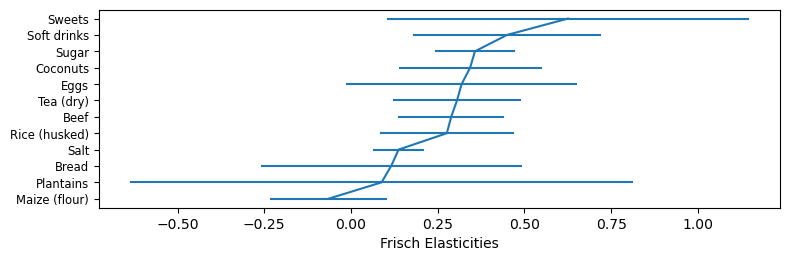

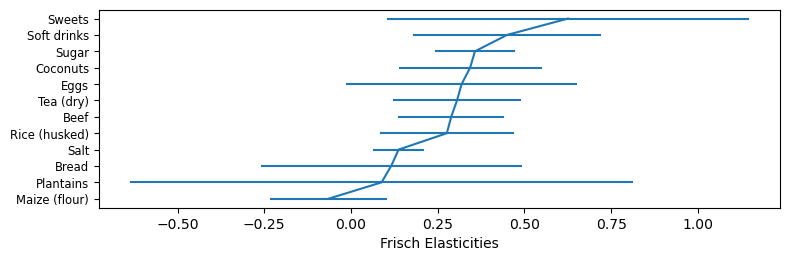

In [10]:
r = rgsn.Regression(y=y, d=d)

beta = r.get_beta()

display(beta.sort_values().to_frame("beta").head(10))
display(beta.sort_values(ascending=False).to_frame("beta").head(10))

r.graph_beta()

## 11. Build reference prices, predicted expenditures, and reference budget

This cell prepares the estimated demand system for simulations.

The key objects are:

- `pbar`: median/reference price for each modeled food
- `xhat`: predicted food expenditures from the demand model
- `xbar`: predicted total household food budgets
- `xref`: the median reference food budget used in later simulations

In our run, the reference budget was about 35,776, and the final modeled demand system used 12 foods. These objects are used for demand curves, Engel curves, nutrient-demand curves, and the subsidy simulation.

In [11]:
pbar = (
    p
    .median(axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

pbar = pbar[pbar > 0]

beta_goods = beta.index.intersection(pbar.index)
pbar = pbar.loc[beta_goods]

xhat = r.predicted_expenditures()
xhat = xhat.loc[xhat.index.get_level_values("j").isin(pbar.index)]

xbar = xhat.groupby(["i", "t", "m"]).sum()
xref = float(xbar.quantile(0.50))

print("Reference budget xref:", round(xref, 2))
print("Number of modeled foods:", len(pbar))

display(pbar.to_frame("median_price").head())
display(xbar.describe().to_frame("household_total_predicted_expenditure"))

Reference budget xref: 35775.69
Number of modeled foods: 12


,median_price
j,
Beef,6658.698361
Bread,2428.959359
Coconuts,1499.718076
Eggs,5544.646307
Maize (flour),1245.413295


,household_total_predicted_expenditure
count,1.487000e+03
mean,1.193045e+05
std,2.965904e+06
min,1.018773e+04
25%,2.668744e+04
50%,3.577569e+04
75%,4.804243e+04
max,1.144047e+08


## 12. Choose an iron-focused policy food

This cell supports our policy focus on iron.

The code searches the food composition table for the iron column, ranks foods by iron content, and chooses the highest-iron food among the foods available in the estimated demand system.

In our run, the model selected eggs as the policy food because eggs had the highest iron content among the foods that remained after aligning expenditures, prices, and the FCT.

This gives us a concrete policy target for the subsidy simulation: a price subsidy on an iron-rich food.

In [12]:
common_fct_goods = fct.index.intersection(pbar.index)

iron_cols = [c for c in fct.columns if "iron" in str(c).lower()]

if iron_cols:
    iron_col = iron_cols[0]

    iron_ranking = (
        fct.loc[common_fct_goods, iron_col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values(ascending=False)
    )

    if len(iron_ranking) > 0:
        policy_good = iron_ranking.index[0]
    else:
        policy_good = pbar.index[0]

    print("Iron column used:", iron_col)
    print("Policy good chosen:", policy_good)

    display(iron_ranking.head(10).to_frame("iron_content"))
else:
    iron_col = None
    iron_ranking = pd.Series(dtype=float)
    policy_good = pbar.index[0]

    print("No iron column found in FCT.")
    print("Fallback policy good:", policy_good)

Iron column used: Iron
Policy good chosen: Eggs


,iron_content
j,
Eggs,59.0
Maize (flour),35.0
Sweets,31.0
Beef,17.0
Rice (husked),6.0
Bread,5.0
Coconuts,4.0
Salt,1.0
Sugar,1.0


## 13. Define price-change and nutrient-demand functions

This cell defines two functions used for policy analysis.

`ceteris_paribus_price()` changes the price of one food while holding all other food prices fixed. This lets us simulate a targeted price policy.

`nutrient_demand()` uses the estimated demand system to predict food quantities at a given budget and price vector, then multiplies those quantities by the food composition table to estimate nutrient demand.

This function is the core of Deliverable 1.6 because it maps predicted food demand into predicted nutrient demand.

In [13]:
def ceteris_paribus_price(j, p0, p=pbar):
    new_p = p.copy()
    new_p.loc[j] = p0
    return new_p


def nutrient_demand(x_budget, prices, r=r, fct=fct):
    quantities = r.demands(x_budget, prices)

    if isinstance(quantities, pd.DataFrame):
        quantities = quantities.squeeze()

    quantities = pd.Series(quantities)
    quantities = quantities.replace([np.inf, -np.inf], np.nan).dropna()

    common_goods = quantities.index.intersection(fct.index)

    if len(common_goods) == 0:
        raise ValueError("No overlapping foods between demanded quantities and FCT.")

    nutrients = fct.loc[common_goods].T @ quantities.loc[common_goods]
    nutrients = nutrients.loc[~nutrients.index.duplicated()]
    return nutrients


def safe_log_df(df):
    return np.log(df.where(df > 0))

## 14. Sanity check the nutrient system

This cell checks that the nutrient-demand function works.

It calculates predicted nutrients at the reference household budget and baseline prices. It also verifies that the result is not empty, contains valid nutrient values, and includes the selected policy food.

The output shows predicted nutrient demand at the reference budget. This confirms that the notebook can move from food demand to nutrient demand.

In [14]:
test_nutrients = nutrient_demand(xref, pbar)

assert len(test_nutrients) > 0
assert test_nutrients.notna().sum() > 0
assert policy_good in pbar.index
assert xref > 0

print("Sanity checks passed.")
display(test_nutrients.dropna().head(15).to_frame("nutrient_demand_at_xref"))

Sanity checks passed.


/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')


,nutrient_demand_at_xref
n,
Energy,25106.168748
Protein,740.420500
Vitamin A,9080.022262
Vitamin D,66.255550
Vitamin E,27.030913
Vitamin C,226.554316
Vitamin B-6,12.879456
Vitamin B-12,89.436448
Calcium,3521.018061


## 15. Demand curve for the policy food

This cell plots demand curves for the selected policy food.

The graph shows how the predicted quantity demanded changes when the price of the policy food changes, holding other food prices fixed. The notebook plots this relationship for three household food-budget levels:

- 25th percentile budget
- median budget
- 75th percentile budget

In our run, the policy food was eggs. The graph shows that predicted egg demand is higher for households with larger budgets and lower when the price of eggs increases.

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

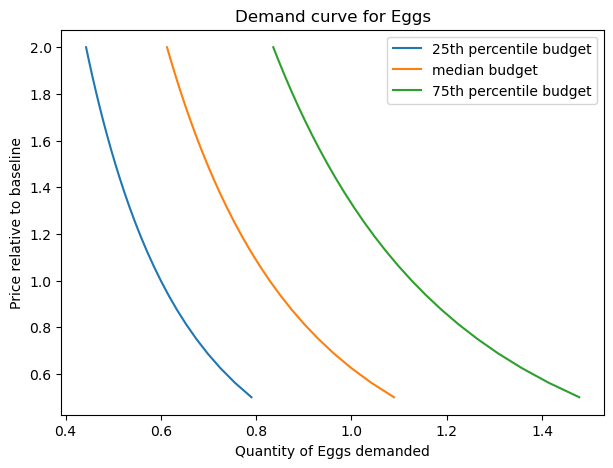

In [15]:
scale = np.linspace(0.5, 2.0, 25)

fig, ax = plt.subplots(figsize=(7, 5))

for budget, label in [
    (xbar.quantile(0.25), "25th percentile budget"),
    (xref, "median budget"),
    (xbar.quantile(0.75), "75th percentile budget"),
]:
    quantities = []

    for s in scale:
        prices_now = ceteris_paribus_price(policy_good, pbar[policy_good] * s)
        demand_now = pd.Series(r.demands(float(budget), prices_now))
        quantities.append(demand_now.get(policy_good, np.nan))

    ax.plot(quantities, scale, label=label)

ax.set_xlabel(f"Quantity of {policy_good} demanded")
ax.set_ylabel("Price relative to baseline")
ax.set_title(f"Demand curve for {policy_good}")
ax.legend()
plt.show()

## 16. Engel curves for top foods

This cell plots Engel curves for the top foods in the model.

An Engel curve shows how predicted expenditure shares change as the household food budget changes. The x-axis is the budget scale relative to the median budget, and the y-axis is the predicted share of the food budget spent on each food.

This helps show which foods become more or less important as households become richer or poorer.

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

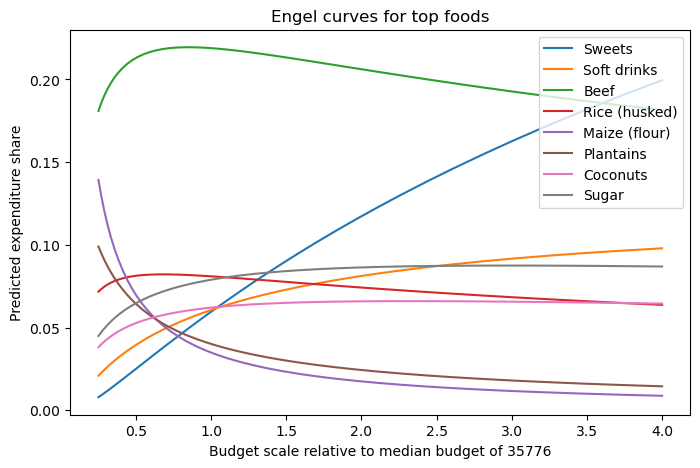

In [16]:
scale = np.geomspace(0.25, 4.0, 40)

engel = pd.DataFrame({
    s: pd.Series(r.expenditures(float(s * xref), pbar)) / float(s * xref)
    for s in scale
}).T

top_goods = (
    xhat
    .groupby("j")
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

top_goods = [g for g in top_goods if g in engel.columns]

fig, ax = plt.subplots(figsize=(8, 5))
engel[top_goods].plot(ax=ax)

ax.set_xlabel(f"Budget scale relative to median budget of {xref:.0f}")
ax.set_ylabel("Predicted expenditure share")
ax.set_title("Engel curves for top foods")
ax.legend(loc="best")
plt.show()

## 17. Convert predicted food expenditures into quantities and nutrients

This cell constructs the main nutrient system for households.

First, it converts predicted food expenditures into predicted quantities by dividing expenditure by price:

`quantity = expenditure / price`

Then it multiplies predicted food quantities by the food composition table:

`predicted nutrients = predicted quantities × nutrient content`

The important outputs are:

- `qhat`: predicted quantities of each food for each household
- `N`: predicted nutrient totals for each household

In our run, `qhat` had 1,487 households and 12 modeled foods, and `N` had 1,487 households and 12 nutrients.

In [17]:
qhat = xhat.unstack("j").divide(pbar, axis=1)

qhat = qhat.replace([np.inf, -np.inf], np.nan)
qhat = qhat.dropna(how="all", axis=0)
qhat = qhat.dropna(how="all", axis=1)

common_q_fct = qhat.columns.intersection(fct.index)

N = qhat[common_q_fct] @ fct.loc[common_q_fct]
N = N.replace([np.inf, -np.inf], np.nan)

print("Predicted quantities shape:", qhat.shape)
print("Predicted nutrient totals shape:", N.shape)

display(qhat.head())
display(N.describe().T.head(20))

Predicted quantities shape: (1487, 12)
Predicted nutrient totals shape: (1487, 12)


,,j,Beef,Bread,Coconuts,Eggs,Maize (flour),Plantains,Rice (husked),Salt,Soft drinks,Sugar,Sweets,Tea (dry)
i,t,m,,,,,,,,,,,,
0001-001-001,2019-20,Mainland Rural,0.598165,0.617173,1.004200,0.135030,5.246176,3.230827,1.387868,0.159283,0.470161,0.298360,0.010100,0.012222
0001-001-003,2019-20,Mainland Rural,0.633789,0.597901,0.895719,0.206826,2.542332,1.575195,1.300846,0.159511,0.915586,0.359043,0.018240,0.015275
0001-001-004,2019-20,Dar Es Salaam,1.099431,1.054342,1.655952,0.401844,1.640532,1.057709,2.355711,0.188148,2.724797,0.583978,0.113928,0.029088
0001-004-001,2019-20,Mainland Rural,0.722644,0.457769,1.270150,0.182934,4.882066,2.272282,2.153237,0.200147,0.810215,0.496005,0.028603,0.019929
0003-001-001,2019-20,Mainland Rural,1.837183,1.110916,3.164252,0.395632,8.398958,6.789749,5.691473,0.295984,2.428887,1.328303,0.048061,0.037016


,count,mean,std,min,25%,50%,75%,max
n,,,,,,,,
Energy,1487.0,81917.628255,1.181036e+06,14130.444968,33669.580245,44225.129210,59590.372486,4.557168e+07
Protein,1487.0,1542.809193,1.164631e+04,364.905572,839.169861,1084.392541,1436.394823,4.492388e+05
Vitamin A,1487.0,13627.776562,3.026407e+05,221.767689,2881.288073,4266.282447,6583.173497,1.167233e+07
Vitamin D,1487.0,36.663474,2.596861e+02,1.690963,16.737104,24.109399,35.336726,9.986298e+03
Vitamin E,1487.0,86.348716,6.151731e+02,13.852610,40.902376,57.476304,82.839498,2.367563e+04
Vitamin C,1487.0,915.653093,2.505482e+04,5.352531,114.715331,180.970796,285.127406,9.662429e+05
Vitamin B-6,1487.0,35.194241,2.171017e+02,6.806205,19.325506,25.338448,33.773061,8.355976e+03
Vitamin B-12,1487.0,61.600214,3.609091e+02,3.210247,30.920321,43.088612,61.940118,1.386686e+04
Calcium,1487.0,7073.697155,1.174257e+05,654.014067,2377.142733,3295.875249,4699.346381,4.530073e+06


## 18. Nutrient demand as household budget changes

This cell studies how predicted nutrient demand changes as the food budget changes.

The code evaluates the nutrient-demand function across a range of budgets, from one-fifth of the reference budget to five times the reference budget. It then plots log nutrient demand for important nutrients such as energy, protein, iron, calcium, vitamin A, vitamin B-6, vitamin B-12, vitamin C, vitamin D, and magnesium.

This graph helps characterize how nutrition changes with household resources. In general, upward-sloping curves mean predicted nutrient demand increases as the household food budget rises.

Nutrients plotted:
['Energy', 'Protein', 'Iron', 'Calcium', 'Vitamin A', 'Vitamin B-6', 'Vitamin B-12', 'Vitamin C', 'Vitamin D', 'Magnesium']


/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

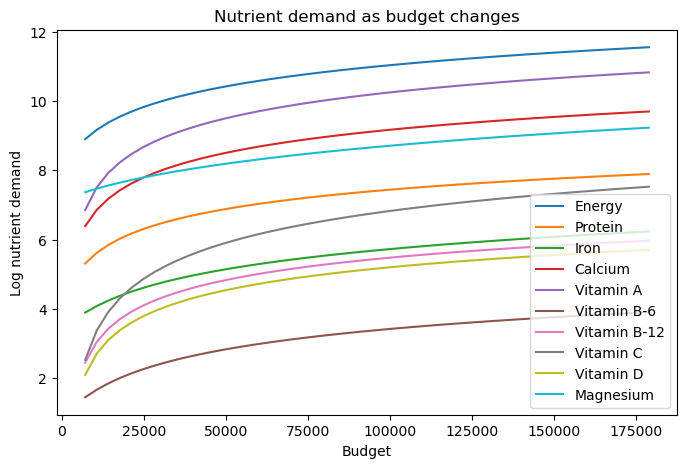

In [18]:
preferred_nutrients = [
    "Energy",
    "Protein",
    "Iron",
    "Calcium",
    "Vitamin A",
    "Vitamin B-6",
    "Vitamin B-12",
    "Vitamin C",
    "Vitamin D",
    "Magnesium",
]

use_nutrients = []

for target in preferred_nutrients:
    matches = [c for c in fct.columns if target.lower() in str(c).lower()]
    for m in matches:
        if m not in use_nutrients:
            use_nutrients.append(m)

if len(use_nutrients) < 5:
    for c in fct.columns:
        if c not in use_nutrients:
            use_nutrients.append(c)
        if len(use_nutrients) >= 5:
            break

print("Nutrients plotted:")
print(use_nutrients)

X = np.linspace(xref / 5, xref * 5, 50)

nutrient_budget_curve = pd.DataFrame({
    myx: nutrient_demand(float(myx), pbar)[use_nutrients]
    for myx in X
}).T

fig, ax = plt.subplots(figsize=(8, 5))
safe_log_df(nutrient_budget_curve).plot(ax=ax)

ax.set_xlabel("Budget")
ax.set_ylabel("Log nutrient demand")
ax.set_title("Nutrient demand as budget changes")
ax.legend(loc="best")
plt.show()

## 19. Nutrient demand as the policy-food price changes

This cell studies how predicted nutrient demand changes when the price of the selected policy food changes.

The code changes the price of the policy food across a range from 50% to 200% of its baseline price, holding the household budget and all other prices fixed. It then plots the resulting nutrient demand.

This graph is useful for policy analysis because it shows whether lowering the price of the selected food could improve nutrient outcomes.

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

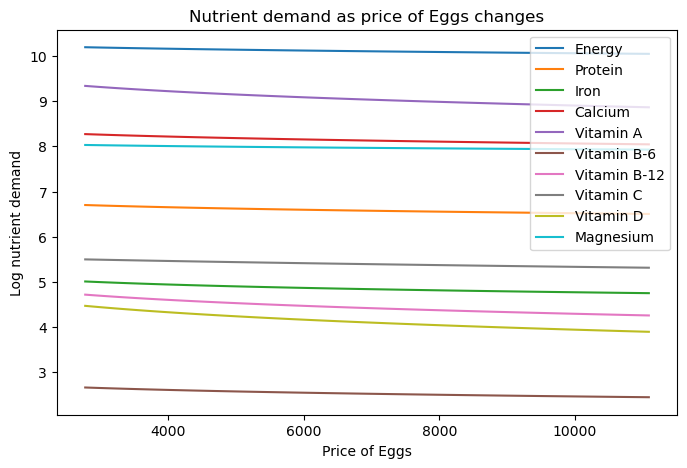

In [19]:
price_scales = np.geomspace(0.5, 2.0, 40)

nutrient_price_curve = pd.DataFrame({
    s * pbar[policy_good]: nutrient_demand(
        xref,
        ceteris_paribus_price(policy_good, pbar[policy_good] * s)
    )[use_nutrients]
    for s in price_scales
}).T

fig, ax = plt.subplots(figsize=(8, 5))
safe_log_df(nutrient_price_curve).plot(ax=ax)

ax.set_xlabel(f"Price of {policy_good}")
ax.set_ylabel("Log nutrient demand")
ax.set_title(f"Nutrient demand as price of {policy_good} changes")
ax.legend(loc="best")
plt.show()

## 20. Simulate a 20% subsidy on the policy food

This cell runs the main policy simulation.

The policy is a 20% subsidy on the selected iron-rich food. In our run, the selected food was eggs.

The cell compares baseline demand and nutrient demand to demand and nutrient demand after the subsidy. The output reports:

- the original price of the policy food
- the subsidized price
- the change in quantity demanded
- the change in predicted nutrient demand

In our run, the 20% egg subsidy increased predicted egg demand by about 9.5%. It also increased predicted iron demand by about 4.2%, along with increases in energy, protein, calcium, vitamin A, vitamin B-12, vitamin D, and other nutrients.

In [20]:
subsidy_rate = 0.20

baseline_prices = pbar.copy()

subsidy_prices = pbar.copy()
subsidy_prices.loc[policy_good] = pbar.loc[policy_good] * (1 - subsidy_rate)

baseline_quantities = pd.Series(r.demands(xref, baseline_prices))
subsidy_quantities = pd.Series(r.demands(xref, subsidy_prices))

baseline_nutrients = nutrient_demand(xref, baseline_prices)
subsidy_nutrients = nutrient_demand(xref, subsidy_prices)

nutrient_change = pd.DataFrame({
    "baseline": baseline_nutrients,
    "after_20pct_subsidy": subsidy_nutrients,
})

nutrient_change["absolute_change"] = (
    nutrient_change["after_20pct_subsidy"] - nutrient_change["baseline"]
)

nutrient_change["pct_change"] = (
    100 * nutrient_change["absolute_change"] / nutrient_change["baseline"]
)

quantity_change = pd.DataFrame({
    "baseline_quantity": baseline_quantities,
    "after_20pct_subsidy_quantity": subsidy_quantities,
})

quantity_change["absolute_change"] = (
    quantity_change["after_20pct_subsidy_quantity"] - quantity_change["baseline_quantity"]
)

quantity_change["pct_change"] = (
    100 * quantity_change["absolute_change"] / quantity_change["baseline_quantity"]
)

print(f"Policy simulation: 20% subsidy on {policy_good}")
print("Old price:", round(pbar.loc[policy_good], 4))
print("New price:", round(subsidy_prices.loc[policy_good], 4))

display(quantity_change.loc[[policy_good]].round(4))

shown_nutrients = [n for n in use_nutrients if n in nutrient_change.index]
display(nutrient_change.loc[shown_nutrients].round(4))

Policy simulation: 20% subsidy on Eggs
Old price: 5544.6463
New price: 4435.717


/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')


,baseline_quantity,after_20pct_subsidy_quantity,absolute_change,pct_change
j,,,,
Eggs,0.8282,0.9068,0.0786,9.4927


,baseline,after_20pct_subsidy,absolute_change,pct_change
n,,,,
Energy,25106.1687,25676.1371,569.9684,2.2702
Protein,740.4205,763.6493,23.2288,3.1372
Iron,131.6125,137.1580,5.5455,4.2135
Calcium,3521.0181,3647.1962,126.1782,3.5836
Vitamin A,9080.0223,9783.0944,703.0721,7.7431
Vitamin B-6,12.8795,13.3242,0.4447,3.4529
Vitamin B-12,89.4364,96.2037,6.7673,7.5666
Vitamin C,226.5543,232.7858,6.2315,2.7505
Vitamin D,66.2555,72.5450,6.2894,9.4927


## 21. Save output files for review and presentation

This cell saves the main results into an `outputs/` folder.

The saved files include:

- estimated demand parameters
- median prices
- predicted household food budgets
- predicted food quantities
- predicted household nutrients
- nutrient-budget curve results
- nutrient-price curve results
- subsidy effects on quantities
- subsidy effects on nutrients
- top iron foods

Saving these outputs makes the project easier to review, reproduce, and use in slides.

In [21]:
OUT_DIR = DATA_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

beta.to_csv(OUT_DIR / "estimated_beta.csv")
pbar.to_csv(OUT_DIR / "median_prices.csv")
xbar.to_csv(OUT_DIR / "predicted_household_budgets.csv")
qhat.to_csv(OUT_DIR / "predicted_quantities.csv")
N.to_csv(OUT_DIR / "predicted_nutrients.csv")
nutrient_budget_curve.to_csv(OUT_DIR / "nutrient_budget_curve.csv")
nutrient_price_curve.to_csv(OUT_DIR / "nutrient_price_curve.csv")
nutrient_change.to_csv(OUT_DIR / "subsidy_nutrient_change.csv")
quantity_change.to_csv(OUT_DIR / "subsidy_quantity_change.csv")

if len(iron_ranking) > 0:
    iron_ranking.to_csv(OUT_DIR / "top_iron_foods.csv")

print("Saved outputs to:")
print(OUT_DIR)

Saved outputs to:
/home/jovyan/EEP153_Borlaug/Project 4 - Tanzania/outputs


## 22. Check for missing RDI/RDA data

This cell checks whether the folder contains an RDI or RDA file.

An RDI/RDA file would provide recommended nutrient intake levels by demographic group. That file is needed to compare predicted household nutrition to recommended nutrition and calculate nutrient adequacy ratios.

Our current Tanzania folder does not include an RDI/RDA file. Because of that, this notebook can estimate the demand system, construct nutrient demand, and simulate a subsidy, but it cannot yet calculate the share of households that are calorie deficient, protein deficient, iron deficient, or vitamin deficient.

This is the main remaining limitation for Deliverable 1.7.

In [22]:
rdi_files = list(DATA_DIR.glob("*RDI*.csv")) + list(DATA_DIR.glob("*RDA*.csv"))

if len(rdi_files) == 0:
    print("Stop here for now.")
    print("No RDI/RDA CSV file was found in this Tanzania folder.")
    print("That means the notebook can estimate demand, map demand to nutrients, and simulate a subsidy,")
    print("but it cannot compute household nutrient adequacy ratios until an RDI/RDA file is added.")
else:
    print("RDI/RDA file found:")
    for f in rdi_files:
        print(" -", f.name)
    print("You can now add the nutrient adequacy section.")

Stop here for now.
No RDI/RDA CSV file was found in this Tanzania folder.
That means the notebook can estimate demand, map demand to nutrients, and simulate a subsidy,
but it cannot compute household nutrient adequacy ratios until an RDI/RDA file is added.


In [24]:
# 1.3 Unit Tests

def test_drop_unnamed():
    df = pd.DataFrame({
        "i": ["001", "002"],
        "Unnamed: 0": [0, 1],
        "Expenditure": [100, 200]
    })

    cleaned = drop_unnamed(df)

    assert "Unnamed: 0" not in cleaned.columns
    assert "i" in cleaned.columns
    assert "Expenditure" in cleaned.columns


def test_standardize_columns():
    df = pd.DataFrame({
        " I ": ["001"],
        " T ": ["2019-20"],
        " M ": ["Mainland Rural"],
        " J ": ["Eggs"],
        "Other Column": [5]
    })

    cleaned = standardize_columns(df)

    assert "i" in cleaned.columns
    assert "t" in cleaned.columns
    assert "m" in cleaned.columns
    assert "j" in cleaned.columns
    assert "Other Column" in cleaned.columns

def test_to_number():
    s = pd.Series(["1,000", " 250.5 ", "not a number", ""])

    nums = to_number(s)

    assert nums.iloc[0] == 1000
    assert nums.iloc[1] == 250.5
    assert pd.isna(nums.iloc[2])
    assert pd.isna(nums.iloc[3])


def test_choose_value_col():
    df = pd.DataFrame({
        "i": ["001", "002", "003"],
        "j": ["Eggs", "Beef", "Rice"],
        "bad_col": ["a", "b", "c"],
        "good_col": ["100", "200", "300"]
    })

    chosen = choose_value_col(df, ["i", "j"], "test value")

    assert chosen == "good_col"


def test_ceteris_paribus_price():
    base_prices = pd.Series({
        "Eggs": 5000,
        "Beef": 7000,
        "Rice": 2000
    })

    new_prices = ceteris_paribus_price("Eggs", 4000, p=base_prices)

    assert new_prices["Eggs"] == 4000
    assert new_prices["Beef"] == 7000
    assert new_prices["Rice"] == 2000
    assert base_prices["Eggs"] == 5000


def test_safe_log_df():
    df = pd.DataFrame({
        "A": [1, 10, 0, -5],
        "B": [100, 0, 5, -1]
    })

    logged = safe_log_df(df)

    assert logged.loc[0, "A"] == np.log(1)
    assert logged.loc[1, "A"] == np.log(10)
    assert pd.isna(logged.loc[2, "A"])
    assert pd.isna(logged.loc[3, "A"])
    assert pd.isna(logged.loc[1, "B"])
    assert pd.isna(logged.loc[3, "B"])


class FakeRegression:
    def demands(self, x_budget, prices):
        return pd.Series({
            "Eggs": 2,
            "Beef": 1,
            "Rice": 3
        })


def test_nutrient_demand():
    fake_r = FakeRegression()

    fake_fct = pd.DataFrame({
        "Energy": [100, 200, 50],
        "Iron": [10, 5, 1],
        "Protein": [6, 20, 3]
    }, index=["Eggs", "Beef", "Rice"])

    fake_prices = pd.Series({
        "Eggs": 5000,
        "Beef": 7000,
        "Rice": 2000
    })

    nutrients = nutrient_demand(
        x_budget=10000,
        prices=fake_prices,
        r=fake_r,
        fct=fake_fct
    )

    assert nutrients["Energy"] == 550
    assert nutrients["Iron"] == 28
    assert nutrients["Protein"] == 41


def test_nutrient_demand_no_overlap():
    class FakeRegressionNoOverlap:
        def demands(self, x_budget, prices):
            return pd.Series({
                "Chicken": 2,
                "Fish": 1
            })

    fake_r = FakeRegressionNoOverlap()

    fake_fct = pd.DataFrame({
        "Energy": [100, 200],
        "Iron": [10, 5]
    }, index=["Eggs", "Beef"])

    fake_prices = pd.Series({
        "Chicken": 5000,
        "Fish": 7000
    })

    try:
        nutrient_demand(
            x_budget=10000,
            prices=fake_prices,
            r=fake_r,
            fct=fake_fct
        )
        assert False
    except ValueError as e:
        assert "No overlapping foods" in str(e)


def run_all_tests():
    test_drop_unnamed()
    test_standardize_columns()
    test_to_number()
    test_choose_value_col()
    test_ceteris_paribus_price()
    test_safe_log_df()
    test_nutrient_demand()
    test_nutrient_demand_no_overlap()

    print("All unit tests passed.")


run_all_tests()

test value value column: good_col
All unit tests passed.
